# Preparations

## Packages

In [ ]:
import os, pathlib, mne, matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import scipy.fft as fft
from scipy.signal import get_window
import numpy as np
import pandas as pd

## Settings

In [ ]:
#
resample_freq = 250


# frequency bands for snapshot feature extraction
freq_bands = {"D": [1, 4],
              "T": [4, 8],
              "A": [8, 14],
              "Bl": [14, 23],
              "Bh": [23, 30]}


band_names = ["Delta: 1 - 3.5 Hz.","Theta: 4 - 7.5 Hz.","Alpha: 8 - 13.5 Hz.","Beta_low: 14 - 22.5 Hz.","Beta_high: 23 - 30 Hz."]


# define all condition levels for which grand averages should be calculated
grand_averages_of_interest = ["starfield", "rs_start", "vel0", "vel1", "vel2", "den1", "den2", "nc", "cc"]

channel_name_list_eeg = ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1',
                         'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7',
                         'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4',
                         'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'FCz', 'Cz']


condition_combination_labels = ["other", "rs", "zero/few", "zero/many", "slow/few", "slow/many", "fast/few", "fast/many"]

single_group = "controls" # False


# define color bar for correlation plots
cmap = "viridis" # for best distingishable color bar

# should plots be displayed in separate windows? The excecution of the script is interupted while a figure window is open. 
separate_plot_windows = False

# determine whether plots should be displayed in separate windows
if separate_plot_windows:
    matplotlib.use('Qt5Agg')

## Directories

In [ ]:
# path to all study data
# path_study_data = pathlib.Path('C:/Users/Mathis Jording/Desktop/MNE Analysis/My analysis/study data/EEGST data/')
path_study_data = pathlib.Path("D:/EEGST data/")

# Folder containing sourcedata (behavioral data, demografic data, montages)
path_sourcedata = path_study_data / 'bids_dataset' / 'sourcedata'

# path to preprocessing folder
path_data_preprocessing =  path_study_data / 'preprocessing'

# group level folder
path_data_grouplevel = path_study_data / 'group_level'

# Output folder
path_output = path_study_data / 'output'

## Functions

### Helper Functions

#### *get_subject_list*
Extracts and return a list of all subject names from demografic data file 

In [ ]:
def get_subject_list(use_raw_demodata = False, exclude_subjects = True, single_group = "controls", selection = []):
    """
    Retrieve a list of subject IDs from demographic data based on filtering criteria.

    Args:
        use_raw_demodata (bool): If True, load raw demographic data. If False, use preprocessed data.
        exclude_subjects (bool): If True, exclude subjects not marked as included.
        single_group (str): Filter to a specific group. Use "controls" for group 1 or "patients" for group 2.
        selection (list[int]): Optional list of subject IDs to include. If provided, only these subjects are returned.

    Returns:
        list[int]: List of subject IDs that meet the specified criteria.
    """
    
    # Load either raw or preprocessed demografic data
    if use_raw_demodata:
        demo_data = pd.read_csv(path_sourcedata / 'demografic_data.csv', encoding='latin-1', sep=";")
    else:
        demo_data = pd.read_csv(pathlib.Path(path_data_grouplevel / 'demografic_availabledata.csv'), encoding='cp1252')

    # only keep subjects from specific group
    if single_group == "controls":
        demo_data = demo_data[demo_data.group == 1]
    elif single_group == "patients":
        demo_data = demo_data[demo_data.group == 2]

    # only keep subjects not marked as excluded
    if exclude_subjects:
        demo_data = demo_data[demo_data.included]

    # extract subject names
    subjects = [int(subject["subject"]) for _ , subject in demo_data.iterrows()]

    if selection:
        subjects = [subject for subject in subjects if subject in selection] 

    return(subjects)

#### *give_subject_filepath()*
Returns paths to subject files

In [5]:
def give_subject_filepath(subject):
    """
    Return the path to the preprocessing files for a given subject.

    Args:
        subject (int or str): Subject identifier.

    Returns:
        pathlib.Path: Path to the subject's preprocessing data directory.
    """

    # subject as three letter string (including leading zeros)
    subject = str(subject).zfill(3)

    # path to subject preprocessing files
    path_data_preprocessing_subj = path_data_preprocessing / subject

    return(path_data_preprocessing_subj)

### Analysis & Plotting Functions

##### *create_topoplots*

Creates average topoplots for each frequency band for the specified condition

In [ ]:
#band_names = ["Delta: 1 - 3.5 Hz.","Theta: 4 - 7.5 Hz.","Alpha: 8 - 13.5 Hz.", "Beta$N_low: 14 - 22.5 Hz.".format(),"Beta_high: 23 - 30 Hz."]


def create_topoplots(condition, save = False, show = True):

    import matplotlib.gridspec as gridspec

    # initiate lists for group averages
    group_power = []

    for _, subject in enumerate(subjects):

        # get path to subject preprocessing files
        path_data_preprocessing_subj = give_subject_filepath(subject)

        # load data
        #fft_data_abs = np.load((pathlib.Path(path_data_preprocessing_subj) / '13a_snapshot_fftpowers.npy'), allow_pickle=True)
        amplitudes = np.load((pathlib.Path(path_data_preprocessing_subj) / '13a_snapshot_amps.npy'), allow_pickle=True)
        features_and_ratings = pd.read_csv(path_data_preprocessing_subj / "16_features_and_behav.csv", index_col = 0)

        # reset index
        features_and_ratings = features_and_ratings.reset_index()

        # only keep epochs from within trials (rs or starfield)
        amplitudes = amplitudes[features_and_ratings["index"]]

        # find condition indices and only keep corresponding epochs
        rs_indices = [index for index, row in features_and_ratings.iterrows() if condition in row["condition"]]
        amplitudes = amplitudes[rs_indices]

        # compute power by squaring
        subject_power_snapshots = amplitudes ** 2

        # compute average over all snapshots of this subject
        subject_power = subject_power_snapshots.mean(axis=0)

        # append averages
        group_power.append(subject_power)

    # turn list of group averages into numpy arrays
    group_power = np.array(group_power)

    # average over subjects
    group_power_avg = group_power.mean(axis = 0)

    # convert unit to Micro Volt
    group_power_avg = group_power_avg * 1e6

    # Loop over bands and compute average power for each band
    band_powers = []
    for _, band_boarders in freq_bands.items():

        band_power = group_power_avg[:, band_boarders[0]*2 : band_boarders[1]*2].copy()

        # average over all frequencies within the band
        band_power_average = band_power.mean(axis = 1)

        band_powers.append(band_power_average)


    # Create Info object
    info = mne.create_info(ch_names=channel_name_list_eeg, sfreq=resample_freq, ch_types="eeg")

    # load and apply vendor-supplied montage
    montage_path = path_sourcedata / 'montage' / 'CACS-64_REF.bvef'
    costum_montage = mne.channels.read_custom_montage(montage_path)
    info.set_montage(costum_montage)


    # Create figure with subplots for each frequency band topoplot as well as scale
    fig = plt.figure(figsize=(15, 3), constrained_layout=True)

    # Create figure with subplots for each frequency band topoplot as well as scale
    gs = gridspec.GridSpec(1, 6, width_ratios=[0.03, 1, 1, 1, 1, 1], wspace=0.1)

    cbar_ax = fig.add_subplot(gs[0])  # narrow axis for colorbar
    axes = [fig.add_subplot(gs[i]) for i in range(1,6)]


    # loop through all frequency bands 
    for ax, (band_nr, band) in zip(axes, enumerate(freq_bands.keys())):

        # plot topoplot for current frequency band
        im, _ = mne.viz.plot_topomap(band_powers[band_nr], info, axes = ax, show=False, vlim = (0, 0.4))

    # Add color bar as legend
    #cbar_ax = axes[-1]
    plt.colorbar(im, cax=cbar_ax, pad=0.01)
    cbar_ax.set_ylabel('Power (µV²)', rotation=270, labelpad=15, fontsize = 12)
    cbar_ax.set_position([0.05, 0.1, 0.015, 0.8])  # (left, bottom, width, height)
    
    cbar_ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
    cbar_ax.set_yticklabels([0, 0.1, 0.2, 0.3, 0.4])  # vertically oriented colorbar


    if save:
        plt.savefig(path_output / f"topoplots_{condition}.pdf", format="pdf")
        plt.savefig(path_output / f"topoplots_{condition}.png", format="png")

    if show:
        plt.show()

#### PSD-Plots



##### *compute_psds()*

Compute psds posterior channels for psds

In [ ]:
def compute_condition_psd(condition, window_type = "hann", fft_res = 0.5):

    # initiate lists for group averages
    group_psds = []

    for _, subject in enumerate(subjects):

        # get path to subject preprocessing files
        path_data_preprocessing_subj = give_subject_filepath(subject)

        # load data
        epochs = mne.read_epochs(path_data_preprocessing_subj / '12a_snapshot_epo.fif', preload = True)

        # make sure that no channel is marked as bad anymore (they were already interpolated in an earlier step)
        epochs.info['bads'] = []

        # Create dictionary
        feature_dict = {}
        for channel in channel_name_list_eeg:
            for key in freq_bands.keys():
                feature_name = f"{channel}_{key}"
                feature_dict[feature_name] = []

        # crop epochs so that data do not include baseline interval
        epochs_filtered = epochs.copy().crop(0, 2)
        epoch_data = epochs_filtered.pick("eeg").get_data()

        # Calculate the number of points for the FFT with 0.5 Hz resolution
        sfreq = epochs_filtered.info['sfreq']
        n_fft_points = int(sfreq / fft_res)  # Number of points for FFT to achieve 0.5 Hz resolution

        if not(window_type == "None"):
            epoch_length = epoch_data.shape[-1]                # length of epoch (samples)
            window = get_window(window_type, epoch_length)          # same length as data
            epoch_data = epoch_data * window

        # Perform FFT
        fft_data = fft.rfft(epoch_data, n=n_fft_points)

        # turn complex to real numbers
        subject_amps = np.abs(fft_data)

        # load condition information
        features_and_ratings = pd.read_csv(path_data_preprocessing_subj / "16_features_and_behav.csv", index_col = 0)

        # reset index
        features_and_ratings = features_and_ratings.reset_index()

        # only keep specific epochs
        subject_amps = subject_amps[features_and_ratings["index"]]

        # identify posterior channels
        posterior_channel_indices = [channel_nr for channel_nr, channel in enumerate(channel_name_list_eeg) if "O" in channel]

        # only keep data from posterior channels
        subject_amps = subject_amps[:,posterior_channel_indices,:]

        # turn complex to real numbers
        subject_amps = np.abs(subject_amps)

        # find condition indices
        indices = [index for index, row in features_and_ratings.iterrows() if condition in row["condition"]]
        #indices = [index for index, row in features_and_ratings.iterrows() if "rs_start" in row["condition"]]

        # only keep epochs from the specified condition
        subject_amps_condition = subject_amps[indices]

        # turn list of group averages into numpy arrays
        subject_amps_condition = np.array(subject_amps_condition)

        # Compute powers (square of magnitude)
        power = subject_amps_condition ** 2  # shape: (epochs, channels, freq_bins)

        # Compute PSD per epoch
        subject_psds = power / (resample_freq * subject_amps_condition[2]) * 2  # PSD formula (scaled for one-sided FFT)

        # log transform
        subject_psds = 10 * np.log10(subject_psds)

        # Average over epochs and channels
        subject_psd = subject_psds.mean(axis=1).mean(axis=0)  # shape: (freq_bins,)

        group_psds.append(subject_psd)

    # turn list of group psds into numpy arrays
    group_psds = np.array(group_psds) # shape: (subjects, freq_bins,)

    # Average over epochs and channels
    group_psd = group_psds.mean(axis=0)  # shape: (freq_bins,)

    return(group_psd)

##### *create_rs_starfield_psdplot_means*

Creates psd plots for comparing RS and starfield snapshots

In [ ]:
def create_rs_starfield_psdplots(subjects, save = False, show = True):

    axis_tick_fontsize = 16

    # create list of frequency bins
    fft_res = 0.5
    n_fft_points = int(resample_freq / fft_res)  # Number of points for FFT to achieve 0.5 Hz resolution
    freqs = fft.rfftfreq(n_fft_points, d=1/resample_freq)

    # mask limiting to input freq_range
    mask = np.logical_and(freqs >= 0.5, freqs <= 40)

    psd_rs = compute_condition_psd("rs_start", window_type = "hann", fft_res = fft_res)
    psd_sf = compute_condition_psd("starfield", window_type = "hann", fft_res = fft_res)

    _, ax = plt.subplots(figsize=(15, 12), sharey=True)

    # plot psd
    rs_line = ax.plot(freqs[mask], psd_rs[mask], color = "blue")
    sf_line = ax.plot(freqs[mask], psd_sf[mask], color = "orange")


    # Axis
    plt.xticks([1, 4, 8, 14, 23, 30], fontsize = axis_tick_fontsize)
    plt.yticks(fontsize = axis_tick_fontsize)
    plt.ylabel('Decibel')
    plt.xlabel('Hz')
    # change x-axis scale to log
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.get_xaxis().set_tick_params(which='minor', size=0)
    ax.get_xaxis().set_tick_params(which='minor', width=0)
        
    # change font sizes
    plt.rc('axes', titlesize = 24, labelsize = 24)    # fontsize of the x and y labels
    plt.rc('legend', fontsize = 22)    # legend fontsize
    plt.rc('figure', titlesize = 26, labelsize = 26)  # fontsize of the figure title
            
    # add legend
    rs_line = mlines.Line2D([], [], color='blue', marker='', markersize=15, label='RS')
    sf_line = mlines.Line2D([], [], color='orange', marker='', markersize=15, label='Starfield')
    ax.legend(handles=[rs_line, sf_line])   

    # Add dotted lines and area to mark frequency bands
    plt.axvline(x = freq_bands["D"][0], color = 'black', linestyle='dashed', label = 'delta band - lower edge')
    plt.axvline(x = freq_bands["T"][0], color = 'black', linestyle='dashed', label = 'theta band - upper edge')
    plt.axvline(x = freq_bands["A"][0], color = 'black', linestyle='dashed', label = 'alpha band - lower edge')
    plt.axvline(x = freq_bands["Bl"][0], color = 'black', linestyle='dashed', label = 'beta low band - upper edge')
    plt.axvline(x = freq_bands["Bh"][0], color = 'black', linestyle='dashed', label = 'beta high band - upper edge')
    plt.axvline(x = freq_bands["Bh"][1], color = 'black', linestyle='dashed', label = 'beta high band - upper edge')
    ax.axvspan(freq_bands["A"][0], freq_bands["A"][1], alpha=0.1, color='red')

    if save:
        psd_folder = path_output / 'psd_plots'
        # create a new folder for psd plots if it does not yet exist
        if not os.path.isdir(psd_folder):
            os.mkdir(psd_folder)
        plt.savefig(psd_folder / f"psd_groupaverage.rs_vs_starfield.pdf", format="pdf")
        plt.savefig(psd_folder / f"psd_groupaverage.rs_vs_starfield.png", format="png")

    # show plot
    if show:
        plt.show()

#### Representation similartiy analysis

##### *plot_correlation_matrix()*

In [9]:
def plot_correlation_matrix(correlation_matrix, vmin = -1, vmax = 1, triangle_only = True, cmap = "viridis"):
    """
    Plot a correlation matrix as a heatmap.

    Args:
        correlation_matrix (pd.DataFrame): Correlation matrix to plot.
        vmin (float): Minimum value for color scale.
        vmax (float): Maximum value for color scale.
        triangle_only (bool): If True, plot only the lower triangle of the matrix.
        cmap (str): Matplotlib colormap to use.

    Returns:
        matplotlib.pyplot: The plot object.
    """

    if triangle_only:
        # build a triangle mask for deleting redundant data in correlation matrix
        lower_triangle_mask = np.tril(np.ones(correlation_matrix.shape), k = 0).astype("bool")
        # only keep triangle of data, loosing the redundant half and the diagonal of the correlation matrix
        correlation_matrix = correlation_matrix.where(lower_triangle_mask)

    # determine color scale min and max based on correlation matrix
    if vmin == 0 and vmax == 0:
        vmin = np.floor(min(correlation_matrix.min())*100)/100
        vmax = np.ceil(max(correlation_matrix.max())*100)/100

    # plotting correlation matrix
    fig = plt.figure()
    ax = fig.add_subplot(111)
    subplotsize=[8.,8.]
    figuresize=[12.,12.]
    
    left = 0.5*(1.-subplotsize[0]/figuresize[0])
    right = 1.-left
    bottom = 0.5*(1.-subplotsize[1]/figuresize[1])
    top = 1.-bottom
    
    fig.subplots_adjust(left=left,right=right,bottom=bottom,top=top)
    
    cax = ax.matshow(correlation_matrix, vmin=vmin, vmax=vmax, cmap = cmap)
    fig.colorbar(cax)
        
    ax.set_xticks(range(0, len(correlation_matrix.columns)))
    ax.set_xticklabels(correlation_matrix.columns, fontsize=10, rotation = 45)
    
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.set_yticks(range(0, len(correlation_matrix.index)))
    ax.set_yticklabels(correlation_matrix.index, fontsize=10)

    # remove box
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    return(plt)

##### *repsimanalysis()*

In [ ]:
def repsimanalysis(absolute = False, save_total = True, show_total = True, triangle = False, save_bands = True, show_bands = True):
    """
    Perform and plot group-level representation similarity analysis (RSA) for the sample and frequency bands.

    Args:
        absolute (bool): If True, use absolute correlation matrices.
        save_total (bool): If True, save the group-level RSA plot.
        show_total (bool): If True, display the group-level RSA plot.
        triangle (bool): If True, plot only the lower triangle of the matrix.
        save_bands (bool): If True, save bandwise RSA plots.
        show_bands (bool): If True, display bandwise RSA plots.

    Saves:
        RSA plots for the group and for each frequency band in the output directory.
    """

    # add a suffix to file names to load and save absolute correlation matrices
    if absolute:
        file_suffix = "_abs"
    else:
        file_suffix = ""

    # load correlation matrix as csv
    sample_correlation_matrix = pd.read_csv(path_data_grouplevel / f"sample_correlation_matrix{file_suffix}.csv", index_col = 0)

    # plot sample matrix (without 'other' conditions)
    correlation_plot = plot_correlation_matrix(sample_correlation_matrix.drop(index = 'other').drop(columns = 'other'), vmin = 0, vmax = 0, triangle_only = triangle)
    if save_total:
        correlation_plot.savefig(path_study_data / "output" / f"RepSimAnalysis_grouplevel{file_suffix}.pdf", format="pdf")
        correlation_plot.savefig(path_study_data / "output" / f"RepSimAnalysis_grouplevel{file_suffix}.png", format="png")
    if show_total:
        correlation_plot.show()

    # load and plot correlation matrices for individual frequency bands (as stored in freq_bands)
    sample_correlation_matrix_band = {}
    _, axes = plt.subplots(1, 5, figsize=(60, 12), sharey=True)

    for band_nr, band in enumerate(freq_bands.keys()):

        print(f"load and plot for band: {band}")

        # load correlation matrix as csv
        sample_correlation_matrix_band[band] = pd.read_csv(path_data_grouplevel / f'sample_correlation_matrix{file_suffix}_{band}.csv', index_col = 0)

        # drop other condition
        sample_correlation_matrix_band[band] = sample_correlation_matrix_band[band].drop(index = 'other').drop(columns = 'other')

        # build a triangle mask for deleting redundant data in correlation matrix
        lower_triangle_mask = np.tril(np.ones(sample_correlation_matrix_band[band].shape), k = 0).astype("bool")
        # only keep triangle of data, loosing the redundant half and the diagonal of the correlation matrix
        sample_correlation_matrix_band[band] = sample_correlation_matrix_band[band].where(lower_triangle_mask)
        
        ax = axes[band_nr]

        ax.imshow(sample_correlation_matrix_band[band], cmap='viridis', vmin = 0, vmax = 1)  # Use imshow for visualization
        ax.set_title(band_names[band_nr], fontsize=14)

        ax.set_xticks(range(0, len(sample_correlation_matrix_band[band].columns)))
        ax.set_xticklabels("")
        
        ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
        ax.set_yticks(range(0, len(sample_correlation_matrix_band[band].index)))
        ax.set_yticklabels(sample_correlation_matrix_band[band].index, fontsize=12)

        # remove box
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

    if save_bands: 
        plt.savefig(path_study_data / "output" / f"RepSimAnalysis_bandwise{file_suffix}.pdf", format="pdf")
        plt.savefig(path_study_data / "output" / f"RepSimAnalysis_bandwise{file_suffix}.png", format="png")

    if show_bands:
        plt.show()

# Analysis

## Subject Selection

In [ ]:
# ----- Settings for subjects -----
# Select subjects for processing / empty list means all subjects will be processed
subject_selection = []

# select subjects from specific group for processing
single_group = "controls"

# Retrieve subject list based on specified paramters (use newly created table for demografic and available data with information about excluded subjects)
subjects = get_subject_list(use_raw_demodata = False, exclude_subjects = True, single_group = single_group, selection = subject_selection)

## Comparing RS and Starfield epochs (Topoplots and Occipital channel PSDs)

In [ ]:
create_topoplots("rs_start", save = True, show = True)

In [ ]:
create_topoplots("starfield", save = True, show = True)

In [ ]:
# create rs vs starfield psd plots
create_rs_starfield_psdplots(subjects, save = True, show = True)

## Representation similarity analyis

In [ ]:
## create representation similarity analysis for the whole sample
repsimanalysis(absolute = False, save = True, plot = True)
repsimanalysis(absolute = True, save_total = False, show_total = True, triangle = True, save_bands = False, show_bands = False)

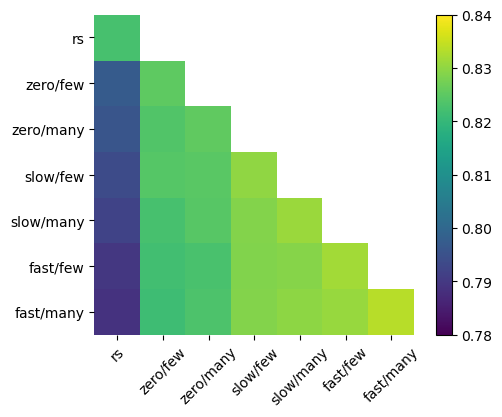

load and plot for band: D
load and plot for band: T
load and plot for band: A
load and plot for band: Bl
load and plot for band: Bh


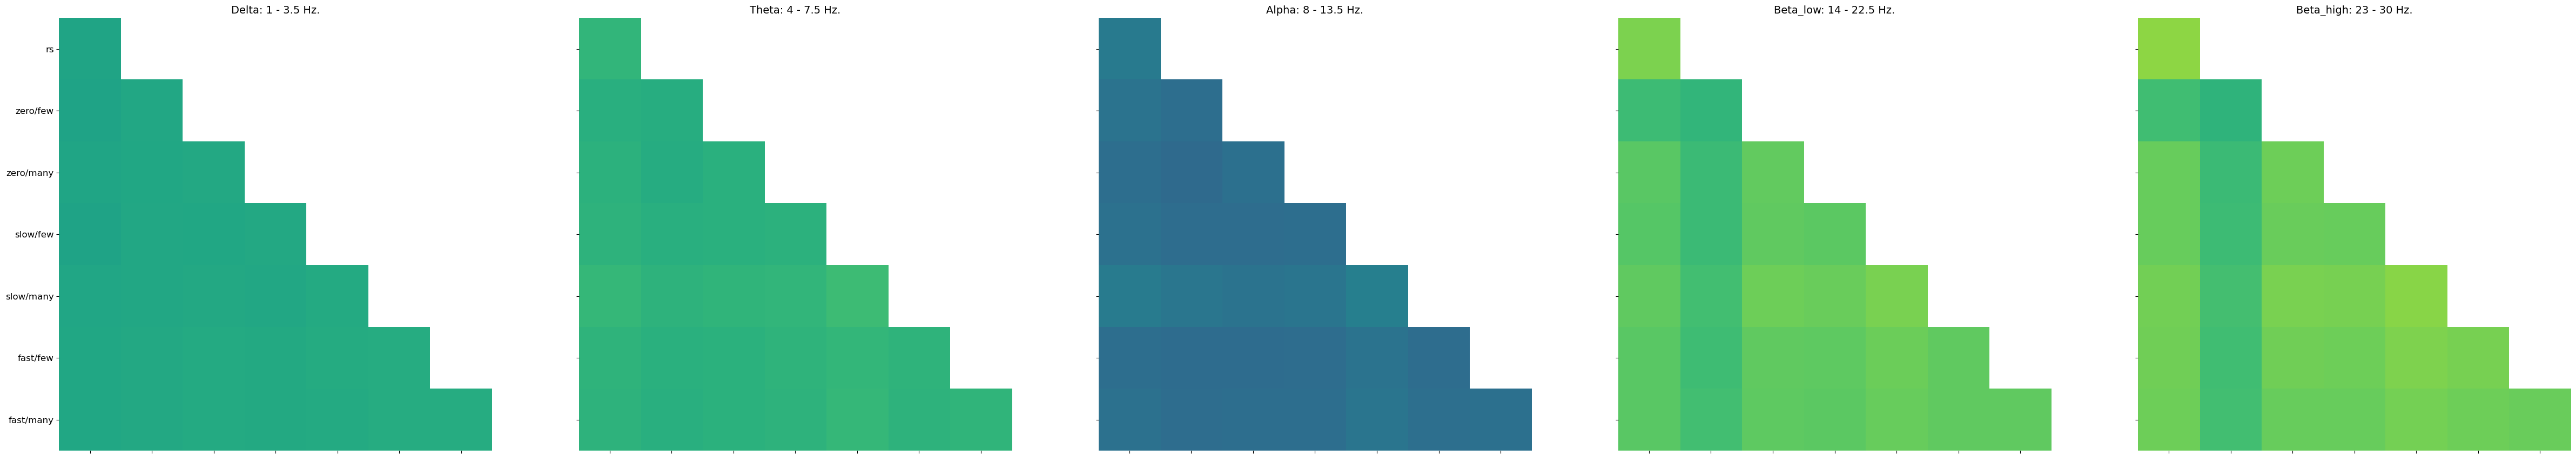

In [ ]:
absolute = False
save_total = True
show_total = True
triangle = True
save_bands = True
show_bands = True

# add a suffix to file names to load and save absolute correlation matrices
if absolute:
    file_suffix = "_abs"
else:
    file_suffix = ""

# load correlation matrix as csv
sample_correlation_matrix = pd.read_csv(path_data_grouplevel / f"sample_correlation_matrix{file_suffix}.csv", index_col = 0)

sample_correlation_matrix.index = condition_combination_labels
sample_correlation_matrix.columns = condition_combination_labels


# plot sample matrix (without 'other' conditions)
correlation_plot = plot_correlation_matrix(sample_correlation_matrix.drop(index = 'other').drop(columns = 'other'), vmin = 0, vmax = 0, triangle_only = triangle)
if save_total:
    correlation_plot.savefig(path_study_data / "output" / f"RepSimAnalysis_grouplevel{file_suffix}.pdf", format="pdf")
    correlation_plot.savefig(path_study_data / "output" / f"RepSimAnalysis_grouplevel{file_suffix}.png", format="png")
if show_total:
    correlation_plot.show()

# load and plot correlation matrices for individual frequency bands (as stored in freq_bands)
sample_correlation_matrix_band = {}
_, axes = plt.subplots(1, 5, figsize=(60, 12), sharey=True)

for band_nr, band in enumerate(freq_bands.keys()):

    print(f"load and plot for band: {band}")

    # load correlation matrix as csv
    sample_correlation_matrix_band[band] = pd.read_csv(path_data_grouplevel / f'sample_correlation_matrix{file_suffix}_{band}.csv', index_col = 0)
    
    sample_correlation_matrix_band[band].index = condition_combination_labels 

    # drop other condition
    sample_correlation_matrix_band[band] = sample_correlation_matrix_band[band].drop(index = 'other').drop(columns = 'other')

    # build a triangle mask for deleting redundant data in correlation matrix
    lower_triangle_mask = np.tril(np.ones(sample_correlation_matrix_band[band].shape), k = 0).astype("bool")
    # only keep triangle of data, loosing the redundant half and the diagonal of the correlation matrix
    sample_correlation_matrix_band[band] = sample_correlation_matrix_band[band].where(lower_triangle_mask)
    
    ax = axes[band_nr]

    ax.imshow(sample_correlation_matrix_band[band], cmap='viridis', vmin = 0, vmax = 1)  # Use imshow for visualization
    ax.set_title(band_names[band_nr], fontsize=14)

    ax.set_xticks(range(0, len(sample_correlation_matrix_band[band].columns)))
    ax.set_xticklabels("")
    # ax.set_xticklabels(correlation_matrix.columns, fontsize=10, rotation = 45)
    
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.set_yticks(range(0, len(sample_correlation_matrix_band[band].index)))
    ax.set_yticklabels(sample_correlation_matrix_band[band].index, fontsize=12)

    # remove box
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)


if save_bands: 
    plt.savefig(path_study_data / "output" / f"RepSimAnalysis_bandwise{file_suffix}.pdf", format="pdf")
    plt.savefig(path_study_data / "output" / f"RepSimAnalysis_bandwise{file_suffix}.png", format="png")

if show_bands:
    plt.show()